In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
um = pd.read_csv("/content/Unemployment in India.csv")

In [ ]:
um.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
um.shape

(768, 7)

In [ ]:
um.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
um.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
um.columns = um.columns.str.strip()

In [ ]:
um.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
um.dropna(inplace=True)

In [ ]:
um['Date'].head()

,Date
0,31-05-2019
1,30-06-2019
2,31-07-2019
3,31-08-2019
4,30-09-2019


In [ ]:
um['Date'] = pd.to_datetime(
    um['Date']
)

/tmp/ipykernel_2272/3333371682.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  um['Date'] = pd.to_datetime(


In [ ]:
um['Month'] = um['Date'].dt.month

In [ ]:
um['Year'] = um['Date'].dt.year

In [ ]:
um.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Month,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


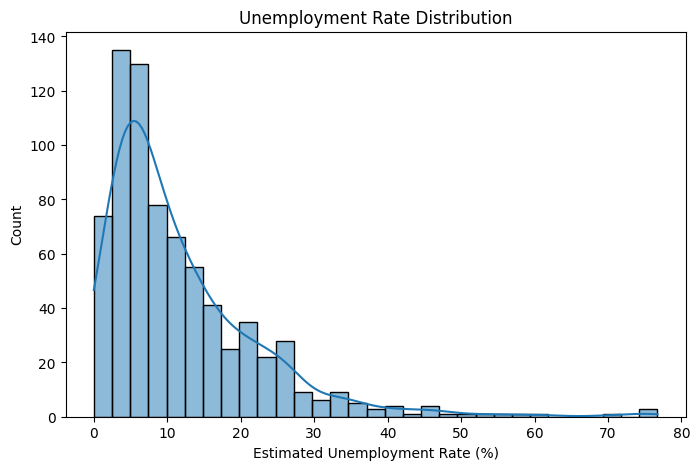

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    um['Estimated Unemployment Rate (%)'],
    kde=True
)
plt.title(
    "Unemployment Rate Distribution"
)
plt.show()

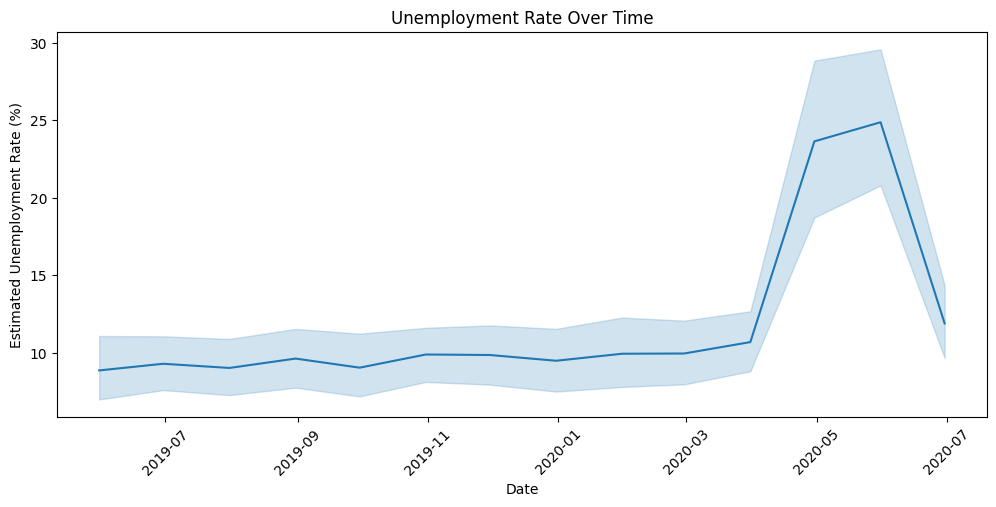

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=um,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)
plt.title(
    "Unemployment Rate Over Time"
)
plt.xticks(rotation=45)
plt.show()

In [ ]:
state_unemployment = (
    um.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(
        ascending=False
    )
)
state_unemployment.head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


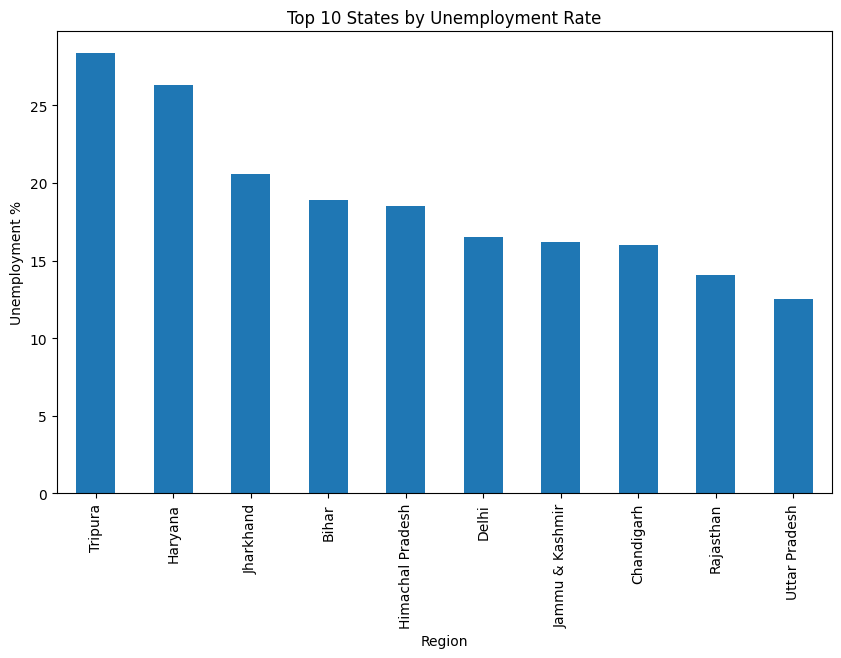

In [ ]:
plt.figure(figsize=(10,6))
state_unemployment.head(10).plot(
    kind='bar'
)
plt.title(
    "Top 10 States by Unemployment Rate"
)
plt.ylabel(
    "Unemployment %"
)
plt.show()

In [ ]:
um.groupby('Area')[
    'Estimated Unemployment Rate (%)'
].mean()

,Estimated Unemployment Rate (%)
Area,
Rural,10.324791
Urban,13.166614


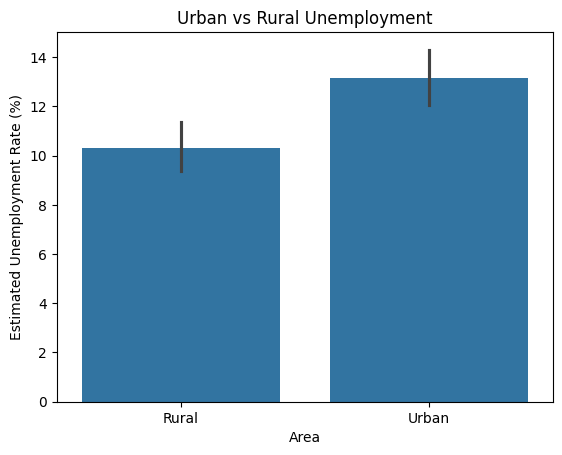

In [ ]:
sns.barplot(
    data=um,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title(
    "Urban vs Rural Unemployment"
)

plt.show()

In [ ]:
covid = um[
    um['Date'].between(
        '2020-03-01',
        '2021-12-31'
    )
]


covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural,3,2020
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural,4,2020
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural,5,2020
13,Andhra Pradesh,2020-06-30,Monthly,0.85,15572975.0,53.76,Rural,6,2020
23,Assam,2020-03-31,Monthly,3.77,9878742.0,47.05,Rural,3,2020


In [ ]:
covid[
'Estimated Unemployment Rate (%)'
].mean()

np.float64(17.774362745098042)

In [ ]:
before = um[
um['Date'] < '2020-03-01'
]
after = um[
um['Date'] >= '2020-03-01'
]
print(
"Before Covid:",
before['Estimated Unemployment Rate (%)'].mean()
)
print(
"During Covid:",
after['Estimated Unemployment Rate (%)'].mean()
)

Before Covid: 9.509533582089553
During Covid: 17.774362745098042


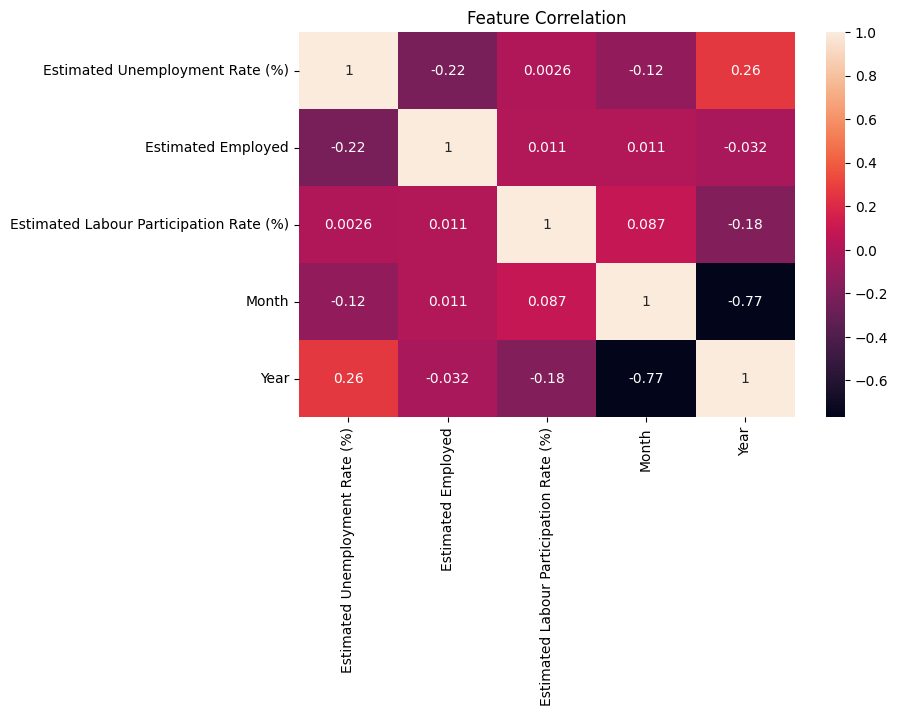

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    um.corr(numeric_only=True),
    annot=True
)
plt.title(
    "Feature Correlation"
)
plt.show()

In [ ]:
um.to_csv(
    "clean_unemployment_data.csv",
    index=False
)